In [1]:
import pandas as pd
import numpy as np

# ===== Load data =====
train = pd.read_csv('/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/train.csv')
test = pd.read_csv('/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print(train.head())

# ===== Step 1: Data types =====
print("\n--- Data Types ---")
print(train.dtypes)

print("\n--- Info ---")
train.info()

# ===== Step 1: Descriptive stats =====
print("\n--- Descriptive Stats (numeric) ---")
print(train.describe())

print("\n--- Descriptive Stats (categorical) ---")
print(train.describe(include='object'))

# ===== Step 2: Missing values check =====
print("\n--- Missing values (train) ---")
print(train.isnull().sum())
print("\nPercentage missing:")
print((train.isnull().sum() / len(train) * 100).round(2))

print("\n--- Missing values (test) ---")
print(test.isnull().sum())

# ===== Step 2: Handle missing values =====
def engineer(df):
    df = df.copy()
    code = df['flight'].str.split('-').str[0]
    # scientific-notation corruption of '6E-xxx' (Indigo) flight codes -> normalize
    code = code.where(~code.str.contains('E', case=False, na=False), '6E')
    df['flight_code'] = code
    return df

train = engineer(train)
test = engineer(test)

# Fill missing airline using the most common airline for that flight code
code_map = train.dropna(subset=['airline']).groupby('flight_code')['airline'] \
    .agg(lambda x: x.value_counts().index[0])

def fill_airline(df):
    mask = df['airline'].isna()
    df.loc[mask, 'airline'] = df.loc[mask, 'flight_code'].map(code_map)
    return df

train = fill_airline(train)
test = fill_airline(test)

# Fallback for any flight codes not seen in train
train['airline'] = train['airline'].fillna('Unknown')
test['airline'] = test['airline'].fillna('Unknown')

print("\n--- Missing values after fix ---")
print("Train:", train['airline'].isnull().sum())
print("Test:", test['airline'].isnull().sum())

# ===== Step 2: check remaining missing values across all columns =====
print("\n--- Final missing value check (train) ---")
print(train.isnull().sum())
print("\n--- Final missing value check (test) ---")
print(test.isnull().sum())

Train shape: (40000, 12)
Test shape: (10000, 11)
   id    airline    flight     source      departure stops  arrival  \
0   0    Vistara    UK-930     Mumbai  Early_Morning   one    Night   
1   1  Air_India    AI-539    Chennai        Evening   one  Morning   
2   2   SpiceJet   SG-8107      Delhi  Early_Morning  zero  Morning   
3   3        NaN  0.00E+00  Hyderabad  Early_Morning  zero  Morning   
4   4  Air_India    AI-569    Chennai  Early_Morning   one  Morning   

  destination     class  duration  days_left  price  
0     Chennai  Business       NaN       40.0  64173  
1      Mumbai   Economy     16.08       26.0   4357  
2     Chennai   Economy      2.92       25.0   3251  
3   Bangalore   Economy      1.50       22.0   1776  
4   Bangalore   Economy      4.83       20.0   3584  

--- Data Types ---
id               int64
airline         object
flight          object
source          object
departure       object
stops           object
arrival         object
destination     obj

In [2]:
# ===== departure (categorical, ~12% missing) =====
# Fill with mode (most frequent value) — 'Morning' is the most common departure time
train['departure'] = train['departure'].fillna(train['departure'].mode()[0])
test['departure'] = test['departure'].fillna(train['departure'].mode()[0])  # use TRAIN mode, no leakage

# ===== stops (categorical, ~6% missing) =====
# Fill with mode — 'one' stop is overwhelmingly the most common (31439/37681)
train['stops'] = train['stops'].fillna(train['stops'].mode()[0])
test['stops'] = test['stops'].fillna(train['stops'].mode()[0])

# ===== duration (numeric, ~7.5% missing) =====
# Duration varies a lot by route, so a per-route median is smarter than a flat overall median
route_duration_median = train.groupby(['source', 'destination'])['duration'].median()

def fill_duration(df):
    mask = df['duration'].isna()
    df.loc[mask, 'duration'] = df.loc[mask].apply(
        lambda row: route_duration_median.get((row['source'], row['destination']), train['duration'].median()),
        axis=1
    )
    return df

train = fill_duration(train)
test = fill_duration(test)

# ===== days_left (numeric, ~11% missing) =====
# No strong grouping signal available, so use overall median (robust to the right-skew we'll see in EDA)
train['days_left'] = train['days_left'].fillna(train['days_left'].median())
test['days_left'] = test['days_left'].fillna(train['days_left'].median())  # use TRAIN median

# ===== Final check =====
print("--- Final missing value check (train) ---")
print(train.isnull().sum())
print("\n--- Final missing value check (test) ---")
print(test.isnull().sum())

--- Final missing value check (train) ---
id             0
airline        0
flight         0
source         0
departure      0
stops          0
arrival        0
destination    0
class          0
duration       0
days_left      0
price          0
flight_code    0
dtype: int64

--- Final missing value check (test) ---
id             0
airline        0
flight         0
source         0
departure      0
stops          0
arrival        0
destination    0
class          0
duration       0
days_left      0
flight_code    0
dtype: int64


In [3]:
# STEP 3 Check for duplicate rows
print("Duplicate rows in train:", train.duplicated().sum())
print("Duplicate rows in test:", test.duplicated().sum())

# If any exist, drop them (train only — never drop rows from test)
if train.duplicated().sum() > 0:
    train = train.drop_duplicates()
    print("New train shape after dropping duplicates:", train.shape)
else:
    print("No duplicates found — nothing to drop.")

Duplicate rows in train: 0
Duplicate rows in test: 0
No duplicates found — nothing to drop.


--- price ---
Q1: 4687.00, Q3: 42521.00, IQR: 37834.00
Lower bound: -52064.00, Upper bound: 99272.00
Number of outliers: 14 (0.03%)
--- duration ---
Q1: 7.00, Q3: 15.42, IQR: 8.42
Lower bound: -5.63, Upper bound: 28.05
Number of outliers: 470 (1.18%)


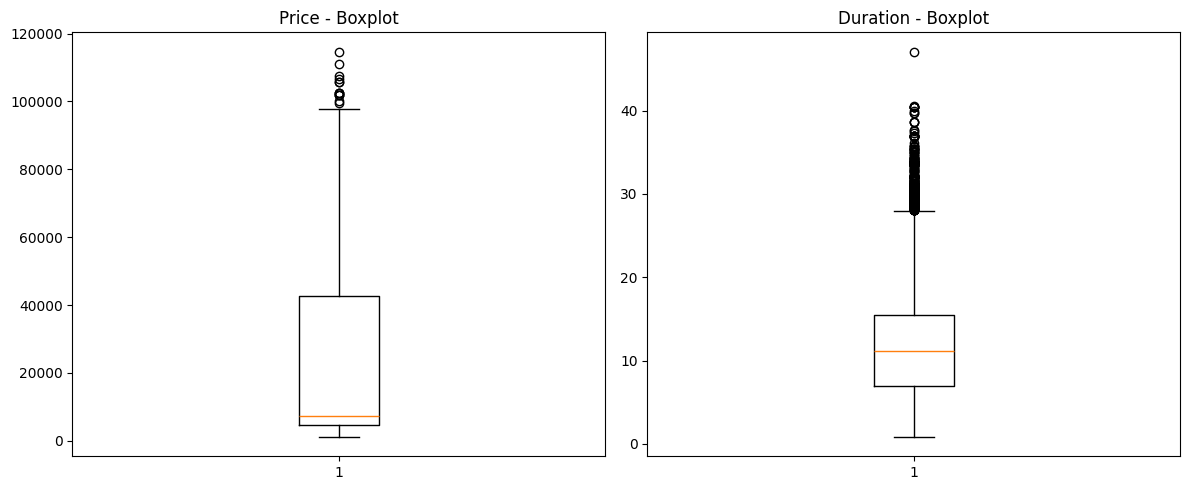

In [4]:
import matplotlib.pyplot as plt
#STEP 4- OUTLIERS
# IQR method: anything beyond 1.5*IQR from Q1/Q3 is flagged as an outlier
def iqr_outlier_report(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"--- {col} ---")
    print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"Lower bound: {lower:.2f}, Upper bound: {upper:.2f}")
    print(f"Number of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    return outliers

# check the two numeric columns most likely to have extreme values
price_outliers = iqr_outlier_report(train, 'price')
duration_outliers = iqr_outlier_report(train, 'duration')

# boxplots to visually confirm what IQR flagged
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot(train['price'])
axes[0].set_title('Price - Boxplot')
axes[1].boxplot(train['duration'])
axes[1].set_title('Duration - Boxplot')
plt.tight_layout()
plt.show()

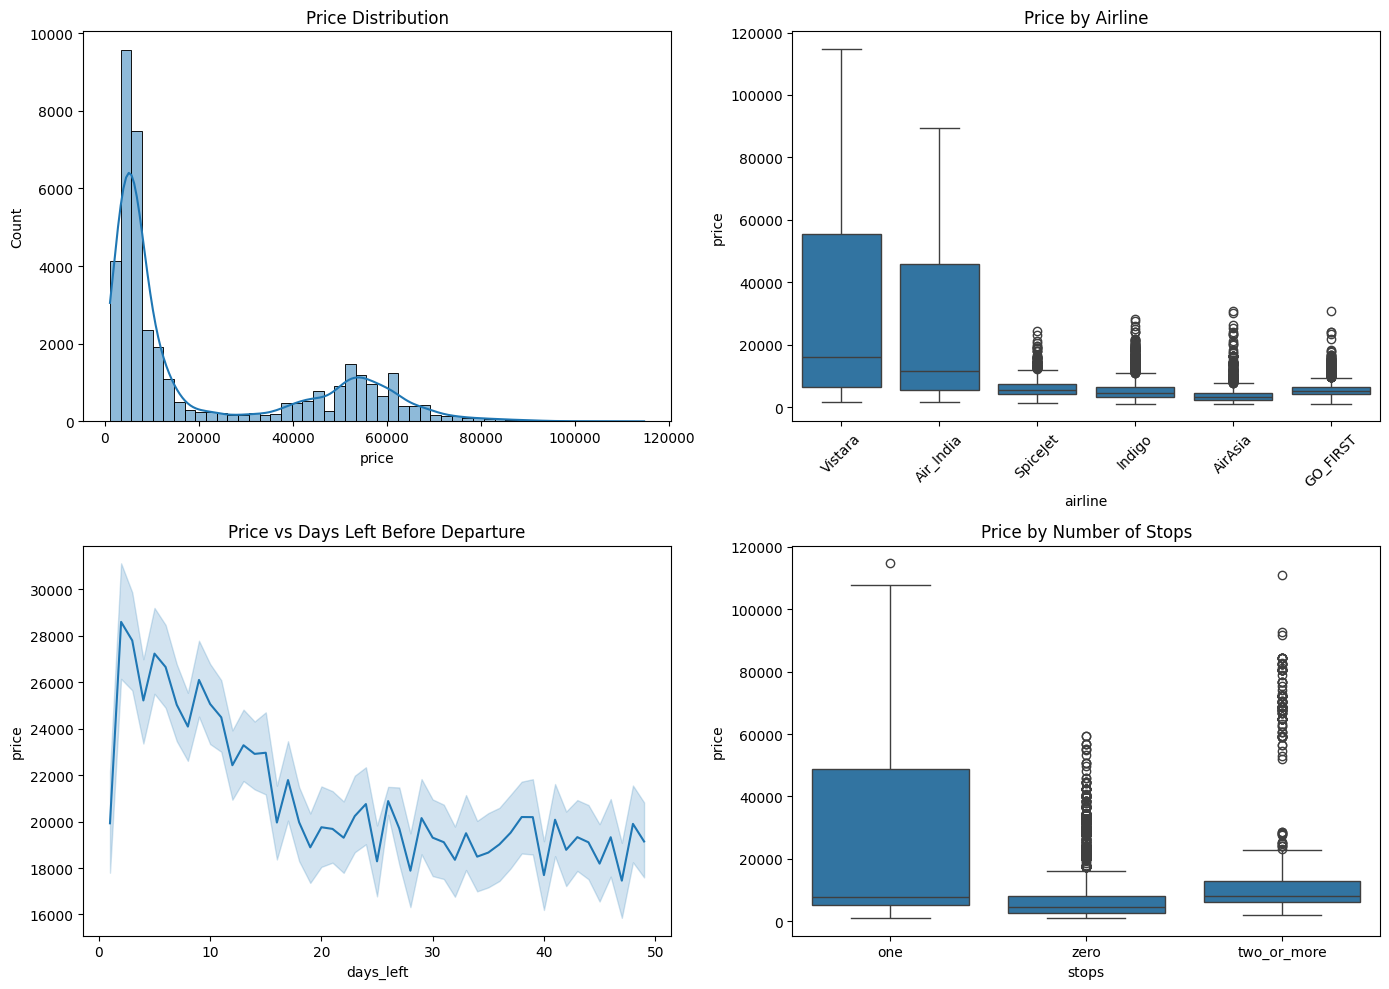

In [5]:
#Step 5 — visualizations
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Price distribution — check skew
sns.histplot(train['price'], bins=50, kde=True, ax=axes[0,0])
axes[0,0].set_title('Price Distribution')

# 2. Price by airline — which airlines are pricier
sns.boxplot(data=train, x='airline', y='price', ax=axes[0,1])
axes[0,1].set_title('Price by Airline')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Price vs days_left — does booking early save money
sns.lineplot(data=train, x='days_left', y='price', ax=axes[1,0])
axes[1,0].set_title('Price vs Days Left Before Departure')

# 4. Price by stops — direct vs layover pricing
sns.boxplot(data=train, x='stops', y='price', ax=axes[1,1])
axes[1,1].set_title('Price by Number of Stops')

plt.tight_layout()
plt.show()

In [6]:
# Step 6 — Scaling & Encoding
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# categorical columns -> one-hot encode (no natural order between airlines, cities, etc.)
# dropped flight_code — it's mostly redundant with airline + route, and 869 categories slows training a lot
cat_cols = ['airline', 'source', 'departure', 'arrival', 'destination', 'class']

# stops has a natural order (zero < one < two_or_more), so encode it as a number, not one-hot
stops_map = {'zero': 0, 'one': 1, 'two_or_more': 2}
train['stops_num'] = train['stops'].map(stops_map)
test['stops_num'] = test['stops'].map(stops_map)

# numeric columns -> may need scaling depending on the model
num_cols = ['duration', 'days_left', 'stops_num']

target = 'price'
X = train[cat_cols + num_cols].copy()
y = train[target]
X_test = test[cat_cols + num_cols].copy()

# preprocessing pipeline: scale numeric, one-hot encode categorical
# sparse_output=False so this works with HistGradientBoosting (which needs dense input)
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

In [7]:
#Step 7 — Build 7 models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score
import pandas as pd

RANDOM_STATE = 42

# same preprocessor from Step 6 gets reused inside every pipeline
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=RANDOM_STATE),
    'Lasso': Lasso(random_state=RANDOM_STATE, max_iter=5000),  # increased from default 1000
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    'XGBoost': XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1)
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []

# loop through all 7 models, build a fresh pipeline each time, run 5-fold CV
for name, model in models.items():
    pipe = Pipeline([
        ('pre', preprocessor),
        ('reg', model)
    ])
    r2_scores = cross_val_score(pipe, X, y, cv=kf, scoring='r2', n_jobs=1)
    rmse_scores = -cross_val_score(pipe, X, y, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=1)
    
    results.append({
        'Model': name,
        'R2 (mean)': r2_scores.mean(),
        'R2 (std)': r2_scores.std(),
        'RMSE (mean)': rmse_scores.mean()
    })
    print(f"{name}: R2 = {r2_scores.mean():.4f} (+/- {r2_scores.std():.4f}), RMSE = {rmse_scores.mean():.2f}")

results_df = pd.DataFrame(results).sort_values('R2 (mean)', ascending=False)
print("\n--- Model Comparison (sorted by R2) ---")
print(results_df)

Linear Regression: R2 = 0.9089 (+/- 0.0019), RMSE = 6859.35
Ridge: R2 = 0.9089 (+/- 0.0019), RMSE = 6859.35
Lasso: R2 = 0.9089 (+/- 0.0019), RMSE = 6859.38
Decision Tree: R2 = 0.9535 (+/- 0.0023), RMSE = 4897.34
Random Forest: R2 = 0.9727 (+/- 0.0011), RMSE = 3755.28
HistGradientBoosting: R2 = 0.9653 (+/- 0.0013), RMSE = 4232.18
XGBoost: R2 = 0.9691 (+/- 0.0010), RMSE = 3992.51

--- Model Comparison (sorted by R2) ---
                  Model  R2 (mean)  R2 (std)  RMSE (mean)
4         Random Forest   0.972682  0.001095  3755.282342
6               XGBoost   0.969130  0.000955  3992.512842
5  HistGradientBoosting   0.965308  0.001276  4232.184633
3         Decision Tree   0.953526  0.002328  4897.344935
1                 Ridge   0.908888  0.001932  6859.349998
0     Linear Regression   0.908888  0.001933  6859.351767
2                 Lasso   0.908888  0.001933  6859.378113


In [8]:
#Step 8 — Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# ===== Random Forest =====
rf_pipe = Pipeline([('pre', preprocessor), ('reg', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))])
rf_params = {
    'reg__n_estimators': [200, 400, 600],
    'reg__max_depth': [10, 20, 30, None],
    'reg__min_samples_split': [2, 5, 10],
    'reg__min_samples_leaf': [1, 2, 4]
}
rf_search = RandomizedSearchCV(rf_pipe, rf_params, n_iter=10, cv=3, scoring='r2',
                                random_state=RANDOM_STATE, n_jobs=-1, verbose=1)
rf_search.fit(X, y)
print("Random Forest best params:", rf_search.best_params_)
print("Random Forest best R2:", rf_search.best_score_)

# ===== HistGradientBoosting =====
hgb_pipe = Pipeline([('pre', preprocessor), ('reg', HistGradientBoostingRegressor(random_state=RANDOM_STATE))])
hgb_params = {
    'reg__max_iter': [200, 400, 600],
    'reg__learning_rate': [0.03, 0.06, 0.1],
    'reg__max_depth': [5, 8, 12, None],
    'reg__l2_regularization': [0, 0.1, 1]
}
hgb_search = RandomizedSearchCV(hgb_pipe, hgb_params, n_iter=10, cv=3, scoring='r2',
                                 random_state=RANDOM_STATE, n_jobs=-1, verbose=1)
hgb_search.fit(X, y)
print("HGB best params:", hgb_search.best_params_)
print("HGB best R2:", hgb_search.best_score_)

# ===== XGBoost =====
xgb_pipe = Pipeline([('pre', preprocessor), ('reg', XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1))])
xgb_params = {
    'reg__n_estimators': [300, 500, 700],
    'reg__learning_rate': [0.03, 0.05, 0.1],
    'reg__max_depth': [5, 7, 9],
    'reg__subsample': [0.7, 0.8, 1.0],
    'reg__colsample_bytree': [0.7, 0.8, 1.0]
}
xgb_search = RandomizedSearchCV(xgb_pipe, xgb_params, n_iter=10, cv=3, scoring='r2',
                                 random_state=RANDOM_STATE, n_jobs=-1, verbose=1)
xgb_search.fit(X, y)
print("XGBoost best params:", xgb_search.best_params_)
print("XGBoost best R2:", xgb_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Random Forest best params: {'reg__n_estimators': 600, 'reg__min_samples_split': 2, 'reg__min_samples_leaf': 1, 'reg__max_depth': None}
Random Forest best R2: 0.971510308186415
Fitting 3 folds for each of 10 candidates, totalling 30 fits
HGB best params: {'reg__max_iter': 600, 'reg__max_depth': None, 'reg__learning_rate': 0.06, 'reg__l2_regularization': 1}
HGB best R2: 0.9679422796598512
Fitting 3 folds for each of 10 candidates, totalling 30 fits
XGBoost best params: {'reg__subsample': 0.7, 'reg__n_estimators': 700, 'reg__max_depth': 9, 'reg__learning_rate': 0.03, 'reg__colsample_bytree': 0.7}
XGBoost best R2: 0.9732776681582133


In [9]:
#Step 9 — Final comparison (before vs after tuning)
# Build a comparison table: baseline CV score vs tuned CV score for the 3 tuned models
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'HistGradientBoosting', 'XGBoost'],
    'Baseline R2': [
        results_df.loc[results_df['Model'] == 'Random Forest', 'R2 (mean)'].values[0],
        results_df.loc[results_df['Model'] == 'HistGradientBoosting', 'R2 (mean)'].values[0],
        results_df.loc[results_df['Model'] == 'XGBoost', 'R2 (mean)'].values[0]
    ],
    'Tuned R2': [
        rf_search.best_score_,
        hgb_search.best_score_,
        xgb_search.best_score_
    ]
})
comparison['Improvement'] = comparison['Tuned R2'] - comparison['Baseline R2']
print(comparison)

# Full comparison across all 7 models (untuned ones stay as-is, tuned ones show their best score)
final_results = results_df.copy()
final_results['R2 (mean)'] = final_results.apply(
    lambda row: rf_search.best_score_ if row['Model'] == 'Random Forest'
    else hgb_search.best_score_ if row['Model'] == 'HistGradientBoosting'
    else xgb_search.best_score_ if row['Model'] == 'XGBoost'
    else row['R2 (mean)'],
    axis=1
)
final_results = final_results.sort_values('R2 (mean)', ascending=False)
print("\n--- Final Model Comparison (best score per model) ---")
print(final_results[['Model', 'R2 (mean)', 'RMSE (mean)']])

                  Model  Baseline R2  Tuned R2  Improvement
0         Random Forest     0.972682  0.971510    -0.001172
1  HistGradientBoosting     0.965308  0.967942     0.002634
2               XGBoost     0.969130  0.973278     0.004147

--- Final Model Comparison (best score per model) ---
                  Model  R2 (mean)  RMSE (mean)
6               XGBoost   0.973278  3992.512842
4         Random Forest   0.971510  3755.282342
5  HistGradientBoosting   0.967942  4232.184633
3         Decision Tree   0.953526  4897.344935
1                 Ridge   0.908888  6859.349998
0     Linear Regression   0.908888  6859.351767
2                 Lasso   0.908888  6859.378113


In [10]:
final_model = xgb_search.best_estimator_
test_preds = final_model.predict(X_test)

submission = pd.DataFrame({
    'id': test['id'],
    'price': test_preds
})
submission.to_csv('submission.csv', index=False)
print("Saved submission.csv")
print(submission.head())

Saved submission.csv
   id         price
0   0   4208.888184
1   1   9764.778320
2   2   5349.999512
3   3  56913.406250
4   4  46933.156250
